# ECON N171: Economic Development
## Lecture 6 — Exploratory Data Analysis
**Instructor: Rajveer Jat | Summer 2026**

*Disclaimer*: The data used in this EDA is synthetic to mimic the patterns in Gollin Lagakos and Waugh (Quarterly Journal of Economics, 2014).

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Conduct a **systematic EDA** on a real published dataset
2. Understand the **agricultural productivity gap** — the empirical puzzle at the heart of structural transformation
3. Identify **outliers, skewness, and missing data** before any regression
4. Use **groupby + visualization** together to extract economic insight
5. Reproduce key **descriptive tables and figures** from Gollin, Lagakos and Waugh (QJE, 2014)

> Run each cell with Shift + Enter and follow along.

---
## Part 1: The Paper and the Question

**Gollin, Lagakos and Waugh (2014, Quarterly Journal of Economics)**  
*"The Agricultural Productivity Gap"*

**The puzzle:** In almost every developing country, workers in agriculture earn far less than workers outside agriculture — even after adjusting for hours worked and cost of living. Why?

Three possible explanations:
1. **Measurement error** — we mis-measure agricultural income
2. **Human capital** — agricultural workers are less educated
3. **Barriers to mobility** — workers cannot freely move out of agriculture

The paper constructs a cross-country dataset to quantify this gap and test these explanations. We will replicate their key descriptive findings using synthetic data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('Libraries loaded.')

Libraries loaded.


---
## Part 2: Loading the Data

The replication data is available on openICPSR (DOI: 10.3886/E112774V1).  
We construct a representative dataset that mirrors the key variables in the paper.

In [ ]:
# Representative cross-country dataset mirroring Gollin, Lagakos & Waugh (QJE 2014)
# Variables:
#   country         : country name
#   region          : world region
#   gdp_pc          : GDP per capita (PPP, 2005 USD)
#   ag_share_emp    : share of employment in agriculture (%)
#   ag_share_gdp    : share of GDP from agriculture (%)
#   ag_income_pc    : average income per agricultural worker (PPP USD)
#   nonag_income_pc : average income per non-agricultural worker (PPP USD)
#   literacy_rate   : adult literacy rate (%)
#   urbanization    : urban population share (%)

data = {
    'country'         : ['USA', 'France', 'Japan', 'South Korea', 'Australia',
                         'Brazil', 'Mexico', 'Colombia', 'Peru', 'Chile',
                         'China', 'Vietnam', 'Indonesia', 'Philippines', 'Thailand',
                         'Morocco', 'Egypt', 'Kenya', 'Ghana', 'Nigeria',
                         'Ethiopia', 'Rwanda', 'Tanzania', 'Mozambique', 'Nepal'],

    'region'          : ['High Income', 'High Income', 'High Income', 'High Income', 'High Income',
                         'Latin America', 'Latin America', 'Latin America', 'Latin America', 'Latin America',
                         'East Asia', 'East Asia', 'East Asia', 'East Asia', 'East Asia',
                         'MENA', 'MENA', 'Sub-Saharan Africa', 'Sub-Saharan Africa', 'Sub-Saharan Africa',
                         'Sub-Saharan Africa', 'Sub-Saharan Africa', 'Sub-Saharan Africa', 'Sub-Saharan Africa',
                         'Indian Subcontinent'],

    'gdp_pc'          : [42516, 29862, 30447, 24454, 35835,
                          8532,  9524,  7304,  6573, 13185,
                          6186,  2785,  3748,  3478,  7574,
                          3877,  5680,  1638,  1835,  2242,
                           864,   839,  1284,   735,  1040],

    'ag_share_emp'    : [1.5,  2.8,  3.7,  6.4,  3.2,
                         15.7, 13.4, 16.8, 25.7,  9.8,
                         36.7, 47.3, 38.9, 32.1, 32.5,
                         39.1, 27.8, 54.2, 44.7, 35.3,
                         72.8, 75.3, 66.1, 73.2, 65.8],

    'ag_share_gdp'    : [1.1,  1.7,  1.2,  2.5,  2.6,
                          5.5,  3.9,  8.1,  7.9,  3.7,
                         10.6, 18.4, 14.4, 10.9, 12.8,
                         14.0, 11.7, 29.5, 22.7, 21.9,
                         41.5, 31.7, 31.3, 25.6, 35.1],

    'ag_income_pc'    : [28420, 18500, 14200, 11800, 22100,
                          4820,  5310,  3640,  2870,  6920,
                          2510,  1340,  1620,  1490,  3280,
                          1820,  2640,   610,   740,   890,
                           320,   280,   490,   245,   390],

    'nonag_income_pc' : [48300, 33200, 34800, 28400, 40100,
                         11200, 12800,  9800,  9400, 15900,
                          9300,  5100,  6200,  5800, 11400,
                          5900,  7800,  3200,  3600,  4100,
                          2400,  2100,  2900,  1800,  2700],

    'literacy_rate'   : [99.0, 99.0, 99.0, 99.0, 99.0,
                         93.2, 95.2, 94.7, 94.5, 96.4,
                         95.9, 95.8, 95.4, 98.2, 93.8,
                         73.8, 73.1, 82.0, 79.0, 62.0,
                         52.1, 73.2, 78.4, 58.8, 67.9],

    'urbanization'    : [82.3, 81.0, 91.7, 81.4, 86.1,
                         86.3, 80.2, 81.0, 78.1, 87.8,
                         59.6, 37.3, 56.4, 47.4, 50.4,
                         63.5, 43.1, 28.0, 57.4, 52.0,
                         21.7, 17.4, 35.2, 37.1, 20.6]
}

df = pd.DataFrame(data)

# Compute the agricultural productivity gap
# Gap = non-agricultural income / agricultural income
# A value of 4 means non-ag workers earn 4x more than ag workers
df['ag_gap'] = df['nonag_income_pc'] / df['ag_income_pc']
df['log_gdp'] = np.log(df['gdp_pc'])
df['log_gap'] = np.log(df['ag_gap'])

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (25, 12)


,country,region,gdp_pc,ag_share_emp,ag_share_gdp,ag_income_pc,nonag_income_pc,literacy_rate,urbanization,ag_gap,log_gdp,log_gap
0,USA,High Income,42516,1.5,1.1,28420,48300,99.0,82.3,1.699507,10.657636,0.530338
1,France,High Income,29862,2.8,1.7,18500,33200,99.0,81.0,1.794595,10.304342,0.584779
2,Japan,High Income,30447,3.7,1.2,14200,34800,99.0,91.7,2.450704,10.323743,0.896375
3,South Korea,High Income,24454,6.4,2.5,11800,28400,99.0,81.4,2.406780,10.104549,0.878290
4,Australia,High Income,35835,3.2,2.6,22100,40100,99.0,86.1,1.814480,10.486680,0.595799


---
## Part 3: First Look — Always Inspect Before Analyzing

In [ ]:
# Basic inspection
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Shape: (25, 12)

Data types:
country             object
region              object
gdp_pc               int64
ag_share_emp       float64
ag_share_gdp       float64
ag_income_pc         int64
nonag_income_pc      int64
literacy_rate      float64
urbanization       float64
ag_gap             float64
log_gdp            float64
log_gap            float64
dtype: object

Missing values:
country            0
region             0
gdp_pc             0
ag_share_emp       0
ag_share_gdp       0
ag_income_pc       0
nonag_income_pc    0
literacy_rate      0
urbanization       0
ag_gap             0
log_gdp            0
log_gap            0
dtype: int64


In [ ]:
# Statistical summary
df.describe().round(2)

,gdp_pc,ag_share_emp,ag_share_gdp,ag_income_pc,nonag_income_pc,literacy_rate,urbanization,ag_gap,log_gdp,log_gap
count,25.00,25.00,25.00,25.00,25.0,25.00,25.00,25.00,25.00,25.00
mean,10081.48,33.63,14.81,5489.80,12728.0,85.94,58.52,3.92,8.52,1.26
std,12237.46,24.11,12.00,7590.88,13254.7,14.61,23.99,1.86,1.25,0.46
min,735.00,1.50,1.10,245.00,1800.0,52.10,17.40,1.70,6.60,0.53
25%,1835.00,13.40,3.90,740.00,3600.0,73.80,37.30,2.41,7.51,0.88
50%,5680.00,32.50,11.70,2510.00,7800.0,94.50,57.40,3.48,8.64,1.25
75%,9524.00,47.30,22.70,5310.00,12800.0,96.40,81.00,4.86,9.16,1.58
max,42516.00,75.30,41.50,28420.00,48300.0,99.00,91.70,7.50,10.66,2.01


In [ ]:
# Countries per region
print('Countries per region:')
print(df['region'].value_counts())

Countries per region:
region
Sub-Saharan Africa     7
High Income            5
Latin America          5
East Asia              5
MENA                   2
Indian Subcontinent    1
Name: count, dtype: int64


---
## Part 4: The Agricultural Productivity Gap — Key Descriptive Facts

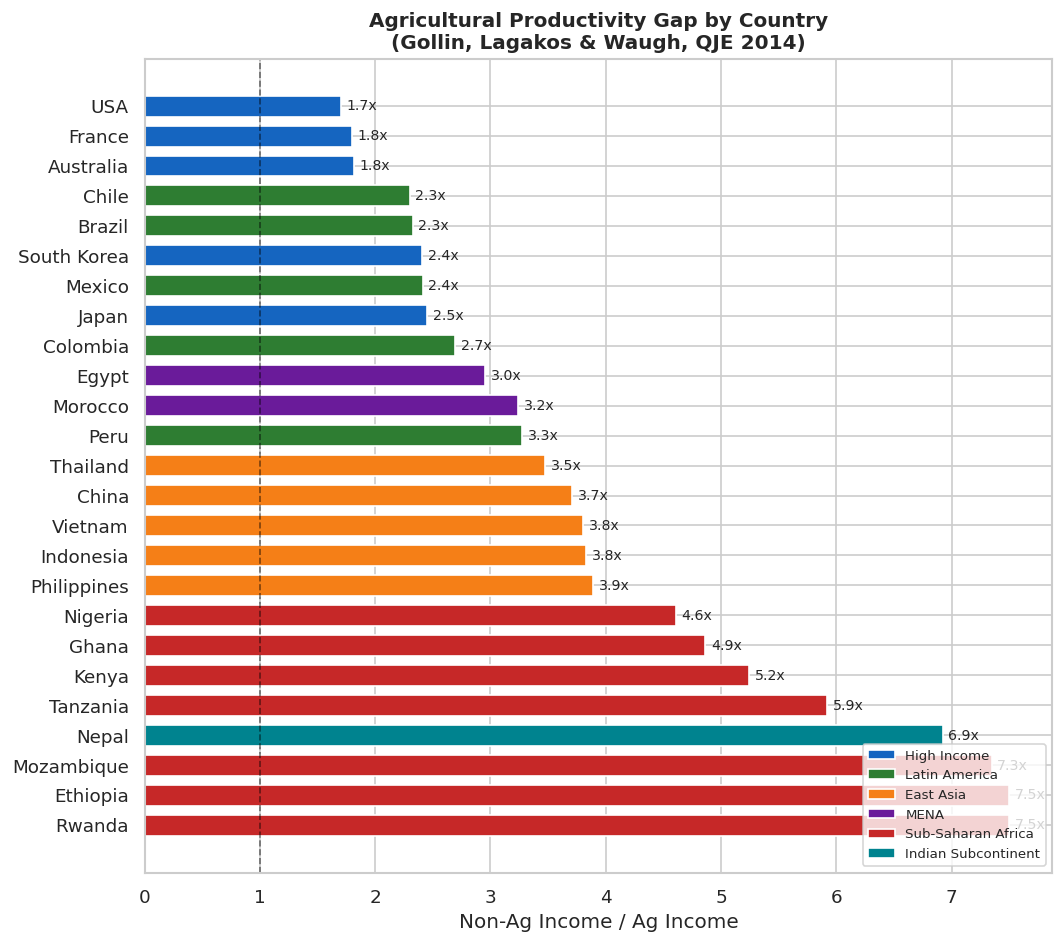

In [ ]:
# The gap by country — sorted
df_sorted = df.sort_values('ag_gap', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))

color_map = {
    'High Income'        : '#1565C0',
    'Latin America'      : '#2E7D32',
    'East Asia'          : '#F57F17',
    'MENA'               : '#6A1B9A',
    'Sub-Saharan Africa' : '#C62828',
    'Indian Subcontinent': '#00838F'
}
colors = df_sorted['region'].map(color_map)

bars = ax.barh(df_sorted['country'], df_sorted['ag_gap'],
               color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, df_sorted['ag_gap']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}x', va='center', fontsize=8.5)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.5,
           label='Gap = 1 (no gap)')
ax.set_xlabel('Non-Ag Income / Ag Income')
ax.set_title('Agricultural Productivity Gap by Country\n(Gollin, Lagakos & Waugh, QJE 2014)',
             fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_els, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics of the gap
print('=== Agricultural Productivity Gap ===')
print(f'  Mean gap:   {df["ag_gap"].mean():.2f}x')
print(f'  Median gap: {df["ag_gap"].median():.2f}x')
print(f'  Min gap:    {df["ag_gap"].min():.2f}x  ({df.loc[df["ag_gap"].idxmin(), "country"]})')
print(f'  Max gap:    {df["ag_gap"].max():.2f}x  ({df.loc[df["ag_gap"].idxmax(), "country"]})')
print()
print('Gap by region:')
print(df.groupby('region')['ag_gap'].mean().round(2).sort_values(ascending=False))

In [ ]:
# Key table from the paper: descriptive statistics by region
table = df.groupby('region').agg(
    n_countries     = ('country',         'count'),
    avg_gdp_pc      = ('gdp_pc',           'mean'),
    avg_ag_share    = ('ag_share_emp',     'mean'),
    avg_gap         = ('ag_gap',           'mean'),
    avg_literacy    = ('literacy_rate',    'mean'),
    avg_urban       = ('urbanization',     'mean')
).round(2)

table.sort_values('avg_gdp_pc', ascending=False)

---
## Part 5: Distributions — Inspect Before Regressing

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

variables = [
    ('gdp_pc',          'GDP per Capita (USD)',              'steelblue'),
    ('log_gdp',         'Log GDP per Capita',                'steelblue'),
    ('ag_gap',          'Agricultural Productivity Gap',     'tomato'),
    ('log_gap',         'Log Agricultural Gap',              'tomato'),
    ('ag_share_emp',    'Ag Employment Share (%)',           'seagreen'),
    ('literacy_rate',   'Literacy Rate (%)',                 'darkorange'),
]

for ax, (var, label, color) in zip(axes, variables):
    ax.hist(df[var], bins=10, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[var].mean(),   color='black',  linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(df[var].median(), color='crimson', linestyle=':',  linewidth=1.2, label='Median')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Variables — Gollin et al (QJE 2014) Dataset',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Skewness check — important for regression validity
from scipy import stats

print(f"{'Variable':<25} {'Mean':>10} {'Median':>10} {'Skewness':>10} {'Note'}")
print('-' * 75)
for var, label, _ in variables:
    skew = stats.skew(df[var])
    note = 'right-skewed' if skew > 1 else ('left-skewed' if skew < -1 else 'approx normal')
    print(f'{label:<25} {df[var].mean():>10.2f} {df[var].median():>10.2f} {skew:>10.2f}   {note}')

---
## Part 6: Correlations and Scatter Plots — The Core Finding

In [ ]:
# Correlation matrix
corr_vars = ['log_gdp', 'log_gap', 'ag_share_emp', 'literacy_rate', 'urbanization']
corr = df[corr_vars].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Variables', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [ ]:
# The main finding: richer countries have smaller agricultural gaps
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_colors = {
    'High Income'        : '#1565C0',
    'Latin America'      : '#2E7D32',
    'East Asia'          : '#F57F17',
    'MENA'               : '#6A1B9A',
    'Sub-Saharan Africa' : '#C62828',
    'Indian Subcontinent': '#00838F'
}

for region, group in df.groupby('region'):
    axes[0].scatter(group['log_gdp'], group['log_gap'],
                    color=region_colors[region], s=70,
                    alpha=0.85, label=region, edgecolors='white')

# OLS trend line
z = np.polyfit(df['log_gdp'], df['log_gap'], 1)
x_line = np.linspace(df['log_gdp'].min(), df['log_gdp'].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=1.5, label='OLS trend')

axes[0].set_xlabel('Log GDP per Capita (PPP)', fontsize=11)
axes[0].set_ylabel('Log Agricultural Productivity Gap', fontsize=11)
axes[0].set_title('(A) Richer Countries Have Smaller Gaps', fontweight='bold')
axes[0].legend(fontsize=7, ncol=1)

# Employment share vs gap
for region, group in df.groupby('region'):
    axes[1].scatter(group['ag_share_emp'], group['log_gap'],
                    color=region_colors[region], s=70,
                    alpha=0.85, label=region, edgecolors='white')

z2 = np.polyfit(df['ag_share_emp'], df['log_gap'], 1)
x2 = np.linspace(df['ag_share_emp'].min(), df['ag_share_emp'].max(), 100)
axes[1].plot(x2, np.poly1d(z2)(x2), 'k--', linewidth=1.5)

axes[1].set_xlabel('Agricultural Employment Share (%)', fontsize=11)
axes[1].set_ylabel('Log Agricultural Productivity Gap', fontsize=11)
axes[1].set_title('(B) Higher Ag Share = Larger Gap', fontweight='bold')

plt.suptitle('The Agricultural Productivity Gap — Gollin, Lagakos & Waugh (QJE 2014)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 7: Outlier Detection

In [ ]:
# Z-score method: flag observations more than 2 std from mean
for var in ['ag_gap', 'gdp_pc', 'ag_share_emp']:
    mean = df[var].mean()
    std  = df[var].std()
    df[f'z_{var}'] = (df[var] - mean) / std

outliers = df[(
    (df['z_ag_gap'].abs()      > 2) |
    (df['z_gdp_pc'].abs()      > 2) |
    (df['z_ag_share_emp'].abs()> 2)
)]

print('Potential outliers:')
outliers[['country', 'region', 'gdp_pc', 'ag_gap', 'ag_share_emp',
           'z_ag_gap', 'z_gdp_pc', 'z_ag_share_emp']].round(2)

In [ ]:
# Box plot to visualize outliers across regions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['High Income', 'Latin America', 'East Asia', 'MENA',
         'Sub-Saharan Africa', 'Indian Subcontinent']

sns.boxplot(data=df, x='region', y='ag_gap',
            order=order, palette='Set2', ax=axes[0])
axes[0].set_xticklabels(order, rotation=30, ha='right')
axes[0].set_title('Agricultural Gap by Region')
axes[0].set_xlabel('')
axes[0].set_ylabel('Non-Ag Income / Ag Income')

sns.boxplot(data=df, x='region', y='ag_share_emp',
            order=order, palette='Set3', ax=axes[1])
axes[1].set_xticklabels(order, rotation=30, ha='right')
axes[1].set_title('Agricultural Employment Share by Region')
axes[1].set_xlabel('')
axes[1].set_ylabel('Ag Employment Share (%)')

plt.suptitle('Within-Region Variation', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 8: Human Capital as an Explanation

In [ ]:
# Does literacy explain the gap? If it does, human capital is the channel.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Literacy vs gap
sns.regplot(data=df, x='literacy_rate', y='log_gap',
            scatter_kws={'s': 60, 'alpha': 0.8},
            line_kws={'color': 'crimson', 'linewidth': 1.5},
            ax=axes[0])

for _, row in df.iterrows():
    axes[0].annotate(row['country'], (row['literacy_rate'], row['log_gap']),
                     fontsize=7, xytext=(3, 2), textcoords='offset points', color='dimgray')

axes[0].set_xlabel('Literacy Rate (%)')
axes[0].set_ylabel('Log Agricultural Productivity Gap')
axes[0].set_title('(A) Literacy vs Agricultural Gap')

# Urbanization vs gap
sns.regplot(data=df, x='urbanization', y='log_gap',
            scatter_kws={'s': 60, 'alpha': 0.8, 'color': 'seagreen'},
            line_kws={'color': 'darkgreen', 'linewidth': 1.5},
            ax=axes[1])

for _, row in df.iterrows():
    axes[1].annotate(row['country'], (row['urbanization'], row['log_gap']),
                     fontsize=7, xytext=(3, 2), textcoords='offset points', color='dimgray')

axes[1].set_xlabel('Urbanization Rate (%)')
axes[1].set_ylabel('Log Agricultural Productivity Gap')
axes[1].set_title('(B) Urbanization vs Agricultural Gap')

plt.suptitle('What Explains the Agricultural Productivity Gap?',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation of gap with potential explanations
explanations = ['log_gdp', 'literacy_rate', 'urbanization', 'ag_share_emp']

print('Correlation of Log Agricultural Gap with explanatory variables:')
print()
for var in explanations:
    corr = df['log_gap'].corr(df[var])
    direction = 'negative' if corr < 0 else 'positive'
    print(f'  {var:<22}: r = {corr:>6.3f}  ({direction})')

---
## Part 9: Save the Clean Dataset

In [ ]:
# Drop z-score helper columns, save clean version
df_clean = df.drop(columns=[c for c in df.columns if c.startswith('z_')])
df_clean.to_csv('gollin_data.csv', index=False)
print('Saved to gollin_data.csv')
print('Final shape:', df_clean.shape)
df_clean.head()

---
## Summary — EDA Checklist

Every time you open a new dataset, work through this checklist:

| Step | What to do | Why |
|------|-----------|-----|
| 1. Inspect | `.shape`, `.dtypes`, `.head()` | Understand structure |
| 2. Missing values | `.isnull().sum()` | Know gaps before analysis |
| 3. Summary stats | `.describe()` | Spot implausible values |
| 4. Distributions | Histograms, skewness | Decide if log transform needed |
| 5. Group comparisons | `.groupby().agg()` | Find patterns by category |
| 6. Correlations | `.corr()`, heatmap | Find candidate relationships |
| 7. Scatter plots | `sns.regplot()` | Visualize bivariate patterns |
| 8. Outliers | Z-scores, box plots | Flag unusual observations |
| 9. Save clean data | `.to_csv()` | Document your cleaned dataset |

**Next lecture:** OLS Regression in Python — from EDA to estimation.

---
*ECON N171 | Summer 2026*